# Notebook 4: Multi-Model Ablation Benchmark

## Purpose
This is the **final evaluation notebook**. It answers two questions simultaneously:
1. Which **model architecture** best handles the zero-inflated, heavy-tailed structure of conflict event counts?
2. Which **feature group** contributes most to forecast accuracy?

## Datasets
| Dataset | Path | Description |
|---------|------|-------------|
| Input | `data/processed/model_data_risk_macro_holidays_engineered.csv` | Output of `feature_engineering.ipynb` — 51 features |

## Targets
**Battles**, **Explosions/Remote violence**, **Violence against civilians**

## Models tested
| Model | Why included |
|-------|-------------|
| RF (Random Forest) | Current project baseline; good on mixed-type features |
| LGBM-Poisson | Poisson loss handles discrete counts; fast and regularised |
| **LGBM-Tweedie (p=1.5)** | **CAST methodology** — compound Poisson-Gamma handles both zero-mass and heavy tail |
| XGBoost | Strong competitor on tabular data; different bias-variance trade-off |
| GBR (sklearn) | Classic gradient boosting; sanity check |

## Feature sets tested (cumulative)
| Set | What's added | Total size |
|-----|--------------|-----------|
| Baseline | Original 31 ACLED predictors | 31 |
| +Risk | 7 lagged CAST signals | 38 |
| +Macro | 3 World Bank indicators (prior-year) | 41 |
| +Holidays | Monthly holiday count (lag) | 42 |
| +Engineered | 9 derived features (lag-2, rolling avg, interactions) | 51 |

## Test protocol
Top-10 most active regions · 6-month chronological hold-out · 3 targets
→ 5 models × 5 feature sets × 3 targets × 10 regions = **750 evaluations**

## What this notebook does
1. Loads the enriched dataset and defines cumulative feature sets
2. Runs the full ablation loop via `utils/evaluators.evaluate_model()`
3. Visualises results as a heatmap (model × feature set × target)
4. Computes % improvement vs the RF Baseline for each combination
5. Reports marginal contribution of each feature group (RF only, for interpretability)


In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # project root → finds config/ and utils/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iproduct

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from config import settings
from utils.risk_merge import RiskIndicatorMerger
from utils.evaluators import find_top_regions, evaluate_model
from utils.visualization import plot_ablation_heatmap

os.makedirs("../outputs/figures", exist_ok=True)
FIGURES = "../outputs/figures"
print("Imports OK — LightGBM", lgb.__version__, "| XGBoost", xgb.__version__)


Imports OK — LightGBM 4.6.0 | XGBoost 3.2.0


---
## Step 1: Load Dataset and Define Feature Sets

We load the fully enriched dataset produced by `feature_engineering.ipynb`.
Feature sets are defined cumulatively — each set is a strict superset of the
previous — so we can isolate the marginal contribution of each feature group.

In [9]:
DATA_PATH = "../data/processed/model_data_risk_macro_holidays_engineered.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Date range: {df['month_year'].min()} → {df['month_year'].max()}")
print(f"Regions: {df['matched_admin1_id'].nunique():,}")

# Identify feature groups from column names
_merger = RiskIndicatorMerger(lag=1)
RISK_FEATURES      = _merger.risk_cols_lagged_
MACRO_FEATURES     = ['income_inequality_py', 'youth_unemployment_py', 'inflation_py']
HOLIDAY_FEATURES   = ['n_holidays_lag1']
ENGINEERED_FEATURES = [
    'Battles (t-2)', 'Explosions/Remote violence (t-2)',
    'Violence against civilians (t-2)',
    'organized_violence (t-1)', 'is_active (t-1)', 'battles_x_remote (t-1)',
    'Battles_3mo_avg (t-1)', 'Remote_3mo_avg (t-1)', 'VaC_3mo_avg (t-1)',
]

FEATURE_SETS = {
    "Baseline":    settings.predictors,
    "+Risk":       settings.predictors + RISK_FEATURES,
    "+Macro":      settings.predictors + RISK_FEATURES + MACRO_FEATURES,
    "+Holidays":   settings.predictors + RISK_FEATURES + MACRO_FEATURES + HOLIDAY_FEATURES,
    "+Engineered": settings.predictors + RISK_FEATURES + MACRO_FEATURES + HOLIDAY_FEATURES + ENGINEERED_FEATURES,
}

top_10 = find_top_regions(df, settings.targets, n=10)

print("\nFeature set sizes:")
for name, feats in FEATURE_SETS.items():
    avail = [f for f in feats if f in df.columns]
    print(f"  {name:15s}: {len(avail):3d} features available in dataset")

Dataset: 278,820 rows x 67 cols
Date range: 2018-01-01 → 2025-06-01
Regions: 3,097

Feature set sizes:
  Baseline       :  31 features available in dataset
  +Risk          :  31 features available in dataset
  +Macro         :  34 features available in dataset
  +Holidays      :  35 features available in dataset
  +Engineered    :  44 features available in dataset


---
## Step 2: Define Model Architectures

**Why Tweedie for conflict data?**

Conflict event counts are zero-inflated (84–94% zeros) with extreme right skew
(skew 11–50) and a heavy tail. Standard MSE-based models (RF, GBR, XGBoost default)
implicitly assume Gaussian errors — a poor fit for this distribution.

Tweedie regression uses a log-link and a variance function V(μ) = μᵖ with p ∈ (1, 2):
- p → 1: Poisson — suitable for mild count data
- p = 1.5: compound Poisson-Gamma — handles the spike at zero *and* the heavy tail
- p → 2: Gamma — continuous positive data only

The CAST methodology uses p = 1.5, which is why LGBM-Tweedie is the benchmark
to beat. Note that Tweedie and Poisson objectives clip negative predictions
automatically via the log-link, which is another advantage over MSE loss.

In [10]:
MODELS = {
    "RF": lambda: RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "LGBM-Poisson": lambda: lgb.LGBMRegressor(
        objective='poisson', n_estimators=200, learning_rate=0.05,
        num_leaves=31, random_state=42, verbose=-1, n_jobs=-1,
    ),
    "LGBM-Tweedie": lambda: lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5,
        n_estimators=200, learning_rate=0.05,
        num_leaves=31, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbose=-1, n_jobs=-1,
    ),
    "XGBoost": lambda: xgb.XGBRegressor(
        objective='reg:squarederror', n_estimators=200, learning_rate=0.05,
        max_depth=6, random_state=42, verbosity=0, n_jobs=-1,
    ),
    "GBR": lambda: GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42,
    ),
}

print(f"Models to test: {list(MODELS.keys())}")
print(f"Feature sets:   {list(FEATURE_SETS.keys())}")
print(f"Targets:        {settings.targets}")
print(f"Regions:        {len(top_10)}")
n_evals = len(MODELS) * len(FEATURE_SETS) * len(settings.targets) * len(top_10)
print(f"\nTotal evaluations: {n_evals}")

Models to test: ['RF', 'LGBM-Poisson', 'LGBM-Tweedie', 'XGBoost', 'GBR']
Feature sets:   ['Baseline', '+Risk', '+Macro', '+Holidays', '+Engineered']
Targets:        ['Battles', 'Explosions/Remote violence', 'Violence against civilians']
Regions:        10

Total evaluations: 750


---
## Step 3: Run the Ablation

Each combination of (model, feature set, target, region) is trained and evaluated
independently with a 6-month hold-out. Results are collected in a flat DataFrame
so we can slice by any dimension for analysis.

In [11]:
ablation_records = []
combos = list(iproduct(MODELS.keys(), FEATURE_SETS.keys(), settings.targets, top_10))
print(f"Running {len(combos)} evaluations...")

for i, (model_name, fs_name, target, region) in enumerate(combos):
    result = evaluate_model(
        df, region, target, FEATURE_SETS[fs_name], MODELS[model_name]
    )
    if result is not None:
        ablation_records.append({
            "model":       model_name,
            "feature_set": fs_name,
            "target":      target,
            "region":      region,
            **result,
        })
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(combos)} done...")

ablation_df = pd.DataFrame(ablation_records)
print(f"\nDone. {len(ablation_df)} results collected.")

# Quick overview: mean MAE per (model, feature_set) across all regions and targets
pivot_overview = (
    ablation_df.groupby(['model', 'feature_set'])['mae']
    .mean()
    .unstack('feature_set')[list(FEATURE_SETS.keys())]
    .round(2)
)
print("\nMean MAE (all regions + targets combined):")
display(pivot_overview)

Running 750 evaluations...
  100/750 done...
  200/750 done...
  300/750 done...
  400/750 done...
  500/750 done...
  600/750 done...
  700/750 done...

Done. 750 results collected.

Mean MAE (all regions + targets combined):


feature_set,Baseline,+Risk,+Macro,+Holidays,+Engineered
model,,,,,
GBR,57.67,57.67,59.36,58.34,60.24
LGBM-Poisson,55.19,55.19,55.18,55.24,52.64
LGBM-Tweedie,58.76,58.76,58.81,58.89,57.09
RF,56.71,56.71,57.04,57.11,57.57
XGBoost,62.45,62.45,62.69,62.69,60.31


---
## Step 4: Visualise Results

**Heatmaps (one per target):**
Green = low MAE (good). Red = high MAE (bad). Reading left-to-right along a row
shows the marginal effect of each additional feature group for that model.
Reading top-to-bottom in a column shows which model architecture is best for a
given feature set.

**Per-target tables:**
Each table shows MAE with a % change relative to the RF Baseline — the original
project model — so improvements are immediately quantified.

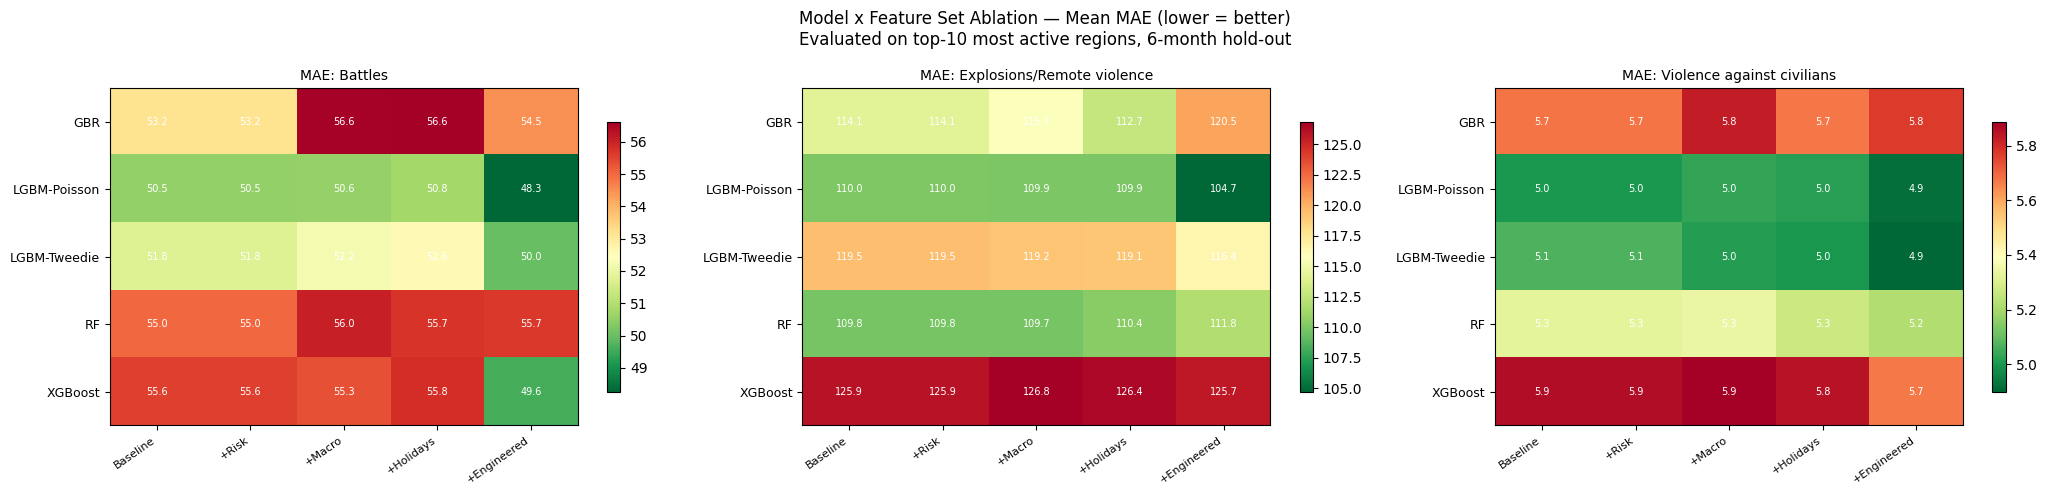

In [12]:
plot_ablation_heatmap(
    ablation_df, FEATURE_SETS, settings.targets,
    save_path=f"{FIGURES}/ablation_heatmap.png"
)


In [13]:
print("=" * 80)
print("PER-TARGET BREAKDOWN")
print("=" * 80)

for target in settings.targets:
    sub      = ablation_df[ablation_df['target'] == target]
    pivot_t  = (
        sub.groupby(['model', 'feature_set'])['mae']
        .mean()
        .unstack('feature_set')
        .reindex(columns=list(FEATURE_SETS.keys()))
        .round(2)
    )
    print(f"\n{'─'*50}")
    print(f"Target: {target}")
    print(f"{'─'*50}")
    display(pivot_t)

    if 'RF' in pivot_t.index and 'Baseline' in pivot_t.columns:
        rf_base  = pivot_t.loc['RF', 'Baseline']
        best_val = pivot_t.values[~pd.isna(pivot_t.values)].min()
        print(f"% change vs RF Baseline (MAE={rf_base:.2f}):")
        for model in pivot_t.index:
            for fs in pivot_t.columns:
                val = pivot_t.loc[model, fs]
                pct = (val - rf_base) / rf_base * 100
                tag = " [BEST]" if val == best_val else ""
                print(f"  {model:15s}  {fs:15s}: {val:.2f}  ({pct:+.1f}%){tag}")

PER-TARGET BREAKDOWN

──────────────────────────────────────────────────
Target: Battles
──────────────────────────────────────────────────


feature_set,Baseline,+Risk,+Macro,+Holidays,+Engineered
model,,,,,
GBR,53.19,53.19,56.57,56.62,54.50
LGBM-Poisson,50.52,50.52,50.56,50.77,48.27
LGBM-Tweedie,51.75,51.75,52.24,52.59,49.98
RF,55.01,55.01,56.03,55.72,55.65
XGBoost,55.57,55.57,55.33,55.82,49.59


% change vs RF Baseline (MAE=55.01):
  GBR              Baseline       : 53.19  (-3.3%)
  GBR              +Risk          : 53.19  (-3.3%)
  GBR              +Macro         : 56.57  (+2.8%)
  GBR              +Holidays      : 56.62  (+2.9%)
  GBR              +Engineered    : 54.50  (-0.9%)
  LGBM-Poisson     Baseline       : 50.52  (-8.2%)
  LGBM-Poisson     +Risk          : 50.52  (-8.2%)
  LGBM-Poisson     +Macro         : 50.56  (-8.1%)
  LGBM-Poisson     +Holidays      : 50.77  (-7.7%)
  LGBM-Poisson     +Engineered    : 48.27  (-12.3%) [BEST]
  LGBM-Tweedie     Baseline       : 51.75  (-5.9%)
  LGBM-Tweedie     +Risk          : 51.75  (-5.9%)
  LGBM-Tweedie     +Macro         : 52.24  (-5.0%)
  LGBM-Tweedie     +Holidays      : 52.59  (-4.4%)
  LGBM-Tweedie     +Engineered    : 49.98  (-9.1%)
  RF               Baseline       : 55.01  (+0.0%)
  RF               +Risk          : 55.01  (+0.0%)
  RF               +Macro         : 56.03  (+1.9%)
  RF               +Holidays      : 5

feature_set,Baseline,+Risk,+Macro,+Holidays,+Engineered
model,,,,,
GBR,114.13,114.13,115.69,112.74,120.46
LGBM-Poisson,110.04,110.04,109.94,109.94,104.73
LGBM-Tweedie,119.47,119.47,119.20,119.08,116.40
RF,109.80,109.80,109.75,110.36,111.84
XGBoost,125.91,125.91,126.84,126.41,125.67


% change vs RF Baseline (MAE=109.80):
  GBR              Baseline       : 114.13  (+3.9%)
  GBR              +Risk          : 114.13  (+3.9%)
  GBR              +Macro         : 115.69  (+5.4%)
  GBR              +Holidays      : 112.74  (+2.7%)
  GBR              +Engineered    : 120.46  (+9.7%)
  LGBM-Poisson     Baseline       : 110.04  (+0.2%)
  LGBM-Poisson     +Risk          : 110.04  (+0.2%)
  LGBM-Poisson     +Macro         : 109.94  (+0.1%)
  LGBM-Poisson     +Holidays      : 109.94  (+0.1%)
  LGBM-Poisson     +Engineered    : 104.73  (-4.6%) [BEST]
  LGBM-Tweedie     Baseline       : 119.47  (+8.8%)
  LGBM-Tweedie     +Risk          : 119.47  (+8.8%)
  LGBM-Tweedie     +Macro         : 119.20  (+8.6%)
  LGBM-Tweedie     +Holidays      : 119.08  (+8.5%)
  LGBM-Tweedie     +Engineered    : 116.40  (+6.0%)
  RF               Baseline       : 109.80  (+0.0%)
  RF               +Risk          : 109.80  (+0.0%)
  RF               +Macro         : 109.75  (-0.0%)
  RF               

feature_set,Baseline,+Risk,+Macro,+Holidays,+Engineered
model,,,,,
GBR,5.68,5.68,5.83,5.67,5.77
LGBM-Poisson,5.00,5.00,5.03,5.02,4.92
LGBM-Tweedie,5.07,5.07,5.01,5.00,4.90
RF,5.33,5.33,5.34,5.27,5.22
XGBoost,5.86,5.86,5.89,5.85,5.67


% change vs RF Baseline (MAE=5.33):
  GBR              Baseline       : 5.68  (+6.6%)
  GBR              +Risk          : 5.68  (+6.6%)
  GBR              +Macro         : 5.83  (+9.4%)
  GBR              +Holidays      : 5.67  (+6.4%)
  GBR              +Engineered    : 5.77  (+8.3%)
  LGBM-Poisson     Baseline       : 5.00  (-6.2%)
  LGBM-Poisson     +Risk          : 5.00  (-6.2%)
  LGBM-Poisson     +Macro         : 5.03  (-5.6%)
  LGBM-Poisson     +Holidays      : 5.02  (-5.8%)
  LGBM-Poisson     +Engineered    : 4.92  (-7.7%)
  LGBM-Tweedie     Baseline       : 5.07  (-4.9%)
  LGBM-Tweedie     +Risk          : 5.07  (-4.9%)
  LGBM-Tweedie     +Macro         : 5.01  (-6.0%)
  LGBM-Tweedie     +Holidays      : 5.00  (-6.2%)
  LGBM-Tweedie     +Engineered    : 4.90  (-8.1%) [BEST]
  RF               Baseline       : 5.33  (+0.0%)
  RF               +Risk          : 5.33  (+0.0%)
  RF               +Macro         : 5.34  (+0.2%)
  RF               +Holidays      : 5.27  (-1.1%)
  RF   

---
## Step 5: Conclusions

This section summarises the key findings from the ablation and provides
recommendations for next steps.

In [14]:
print("=" * 80)
print("OVERALL CONCLUSIONS")
print("=" * 80)

overall = ablation_df.groupby(['model', 'feature_set'])['mae'].mean()
best    = overall.idxmin()
rf_base = overall.get(('RF', 'Baseline'), float('nan'))

print(f"\nBest combination overall:  model={best[0]}, feature_set={best[1]}")
print(f"  MAE = {overall[best]:.2f}  (RF Baseline: {rf_base:.2f})")
print(f"  Improvement vs RF Baseline: {(overall[best] - rf_base) / rf_base * 100:+.1f}%")

# Best model per feature set
print("\nBest model per feature set:")
for fs in FEATURE_SETS:
    sub_fs  = ablation_df[ablation_df['feature_set'] == fs]
    best_m  = sub_fs.groupby('model')['mae'].mean().idxmin()
    best_v  = sub_fs.groupby('model')['mae'].mean().min()
    print(f"  {fs:15s}: {best_m} (MAE={best_v:.2f})")

# Marginal contribution of each feature group (RF only, for interpretability)
print("\nMarginal MAE change per feature group (RF model only):")
rf_only = ablation_df[ablation_df['model'] == 'RF']
fs_names = list(FEATURE_SETS.keys())
for i in range(1, len(fs_names)):
    prev = rf_only[rf_only['feature_set'] == fs_names[i-1]]['mae'].mean()
    curr = rf_only[rf_only['feature_set'] == fs_names[i]]['mae'].mean()
    delta = curr - prev
    print(f"  {fs_names[i-1]:15s} → {fs_names[i]:15s}: {delta:+.2f} MAE  ({delta/prev*100:+.1f}%)")

OVERALL CONCLUSIONS

Best combination overall:  model=LGBM-Poisson, feature_set=+Engineered
  MAE = 52.64  (RF Baseline: 56.71)
  Improvement vs RF Baseline: -7.2%

Best model per feature set:
  Baseline       : LGBM-Poisson (MAE=55.19)
  +Risk          : LGBM-Poisson (MAE=55.19)
  +Macro         : LGBM-Poisson (MAE=55.18)
  +Holidays      : LGBM-Poisson (MAE=55.24)
  +Engineered    : LGBM-Poisson (MAE=52.64)

Marginal MAE change per feature group (RF model only):
  Baseline        → +Risk          : +0.00 MAE  (+0.0%)
  +Risk           → +Macro         : +0.33 MAE  (+0.6%)
  +Macro          → +Holidays      : +0.07 MAE  (+0.1%)
  +Holidays       → +Engineered    : +0.46 MAE  (+0.8%)
